In [2]:
from src.ColorsAnalysis import *
from matplotlib.ticker import AutoMinorLocator, MultipleLocator
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt
from IPython.display import clear_output
plt.style.use('properties.mplstyle')

In [3]:
results_folder = "../results/ColorAnalysis/3D"
create_folder(results_folder)

Folder created: ../results/ColorAnalysis/3D


In [4]:
df_dynamic = pd.read_csv("../SOP_data/all_colors_dynamic.dat", sep=' ')
df_dynamic

,type_perc,dim,L,f_T,c,num_colors,P0,p0,N_samples,rho,nc,nc_err,nc_std,stat_window
0,bond,2,1024,0.001000,0.01,1,0.5,0.8,606,1.00,0.0,0.0,0.0,300
1,bond,2,2048,0.001000,0.01,1,0.5,0.8,306,1.00,0.0,0.0,0.0,300
2,bond,2,4096,0.001000,0.01,1,0.5,0.8,156,1.00,0.0,0.0,0.0,300
3,bond,2,8192,0.001000,0.01,1,0.5,0.8,81,1.00,0.0,0.0,0.0,300
4,bond,2,1024,0.005308,0.01,1,0.5,0.8,404,1.00,0.0,0.0,0.0,300
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6563,bond,3,1024,0.473737,0.20,4,1.0,0.6,5,0.25,4.0,0.0,0.0,300
6564,bond,3,128,0.500000,0.20,4,1.0,0.6,200,0.25,4.0,0.0,0.0,300
6565,bond,3,256,0.500000,0.20,4,1.0,0.6,150,0.25,4.0,0.0,0.0,300
6566,bond,3,512,0.500000,0.20,4,1.0,0.6,25,0.25,4.0,0.0,0.0,300


In [5]:
df_series = pd.read_csv('../SOP_data/all_data_dynamic.dat', sep=' ')
df_series

,type_perc,dim,L,f_T,c,nc,rho,p0,P0,order,...,N_samples_perc,p_mean,p_err,f_mean,f_err,z_max_mean,z_max_err,z_stat_mean,z_stat_err,stat_window
0,bond,2,8192,0.022538,0.01,1,1.00,0.8,0.5,0,...,1,0.501080,0.000000,0.022540,0.000000,8192.0,0.0,391.000000,0.000000,300
1,bond,2,8192,0.026846,0.01,1,1.00,0.8,0.5,0,...,2,0.501816,0.000865,0.026897,0.000006,8192.0,0.0,328.000000,12.000000,300
2,bond,2,4096,0.031154,0.01,1,1.00,0.8,0.5,0,...,1,0.501357,0.000000,0.031115,0.000000,4096.0,0.0,294.000000,0.000000,300
3,bond,2,8192,0.031154,0.01,1,1.00,0.8,0.5,0,...,3,0.501402,0.000317,0.031213,0.000025,8192.0,0.0,355.666667,4.666667,300
4,bond,2,4096,0.035462,0.01,1,1.00,0.8,0.5,0,...,4,0.501608,0.000648,0.035541,0.000043,4096.0,0.0,301.000000,12.935739,300
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14271,bond,3,512,0.500000,0.20,4,0.25,0.6,1.0,3,...,25,1.000000,0.000000,0.250196,0.000191,512.0,0.0,320.000000,0.000000,300
14272,bond,3,1024,0.500000,0.20,4,0.25,0.6,1.0,0,...,5,1.000000,0.000000,0.250027,0.000210,1024.0,0.0,320.000000,0.000000,300
14273,bond,3,1024,0.500000,0.20,4,0.25,0.6,1.0,1,...,5,1.000000,0.000000,0.250014,0.000276,1024.0,0.0,320.000000,0.000000,300
14274,bond,3,1024,0.500000,0.20,4,0.25,0.6,1.0,2,...,5,1.000000,0.000000,0.250026,0.000280,1024.0,0.0,320.000000,0.000000,300


[0.01, 0.03, 0.05, 0.1, 0.15, 0.2]
c = 0.01
ft=0.001, L = 128
ft=0.001, L = 256
ft=0.02726316, L = 512
ft=0.001, L = 1024
==
c = 0.03
ft=0.02726316, L = 128
ft=0.02726316, L = 256
ft=0.02726316, L = 512
ft=0.001, L = 1024
==
c = 0.05
ft=0.02726316, L = 128
ft=0.02726316, L = 256
ft=0.02726316, L = 512
ft=0.02726316, L = 1024
==
c = 0.1
ft=0.02726316, L = 128
ft=0.02726316, L = 256
ft=0.02726316, L = 512
ft=0.02726316, L = 1024
==
c = 0.15
ft=0.02726316, L = 128
ft=0.02726316, L = 256
ft=0.02726316, L = 512
ft=0.02726316, L = 1024
==
c = 0.2
ft=0.02726316, L = 128
ft=0.02726316, L = 256
ft=0.02726316, L = 512
ft=0.02726316, L = 1024
==


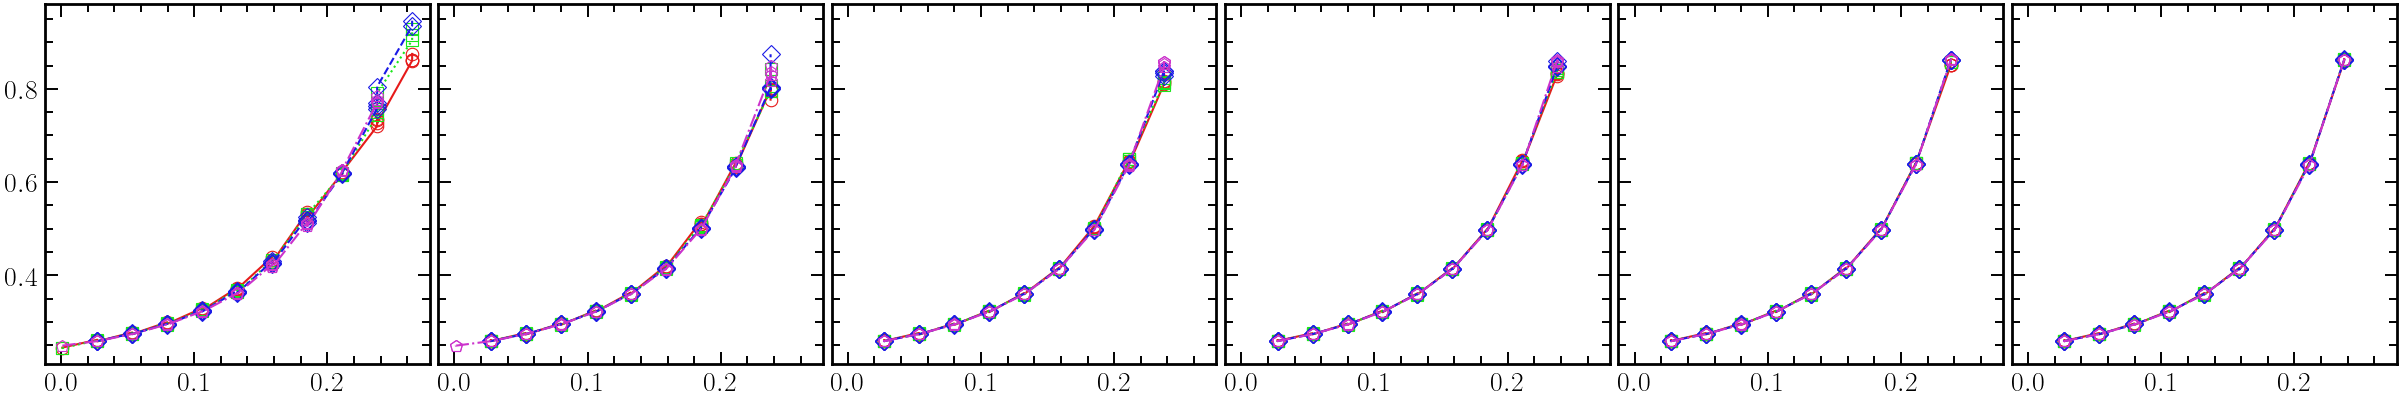

In [46]:

L_lst = [128, 256, 512, 1024]
ns = 4
#c_lst = [0.1, 0.01, 0.15, 0.2, 0.03, 0.05]
c_lst = [0.01, 0.03, 0.05, 0.1, 0.15, 0.2]
print(c_lst)
#c = 0.15
window = 300
base = 4
fig, axes = plt.subplots(1, len(c_lst), figsize=(len(c_lst)*base, base), constrained_layout=True, sharey='row', sharex='row')
markers = ['o', 's', 'D', 'p']
x_min = 0
for idx, ax in enumerate(axes.flatten()):
    c = c_lst[idx]

    print(f'c = {c}')
    for idx_L, L in enumerate(L_lst):
        df_d = df_series[(df_series['c']==c) & (df_series['nc']==ns) & (df_series['p0']==0.6) & (df_series['dim']==3) & (df_series['L']==L) & (df_series['stat_window']==window)]
        
        df_trunc = df_d[df_d['p_mean']<=0.95]
        
        ft = df_trunc['f_T']
        p = df_trunc['p_mean']
        
        ax.plot(ft, p ,marker=markers[idx_L],label=f'$L= {L}$')
        print(f"ft={min(ft)}, L = {L}")
    print("==")
#    ax.set_xlim(xmin, xmax)
# plt.legend()
# plt.xlabel(f'$f_T$')
# plt.ylabel(f'$n_s$')
# plt.title(f'$c={c}$, $n_s={ns}$, dim$=3$')
#plt.xlim(0,0.02)
plt.savefig("teste.pdf")
plt.show()



[0.01, 0.03, 0.05, 0.1, 0.15, 0.2]
0.02726316
0.02726316
0.02726316
0.02726316
0.05352632
0.02726316
0.02726316
0.02726316
0.05352632
0.02726316
0.02726316
0.02726316
0.05352632
0.02726316
0.02726316
0.02726316
0.05352632
0.05352632
0.02726316
0.02726316
0.05352632
0.05352632
0.02726316
0.02726316


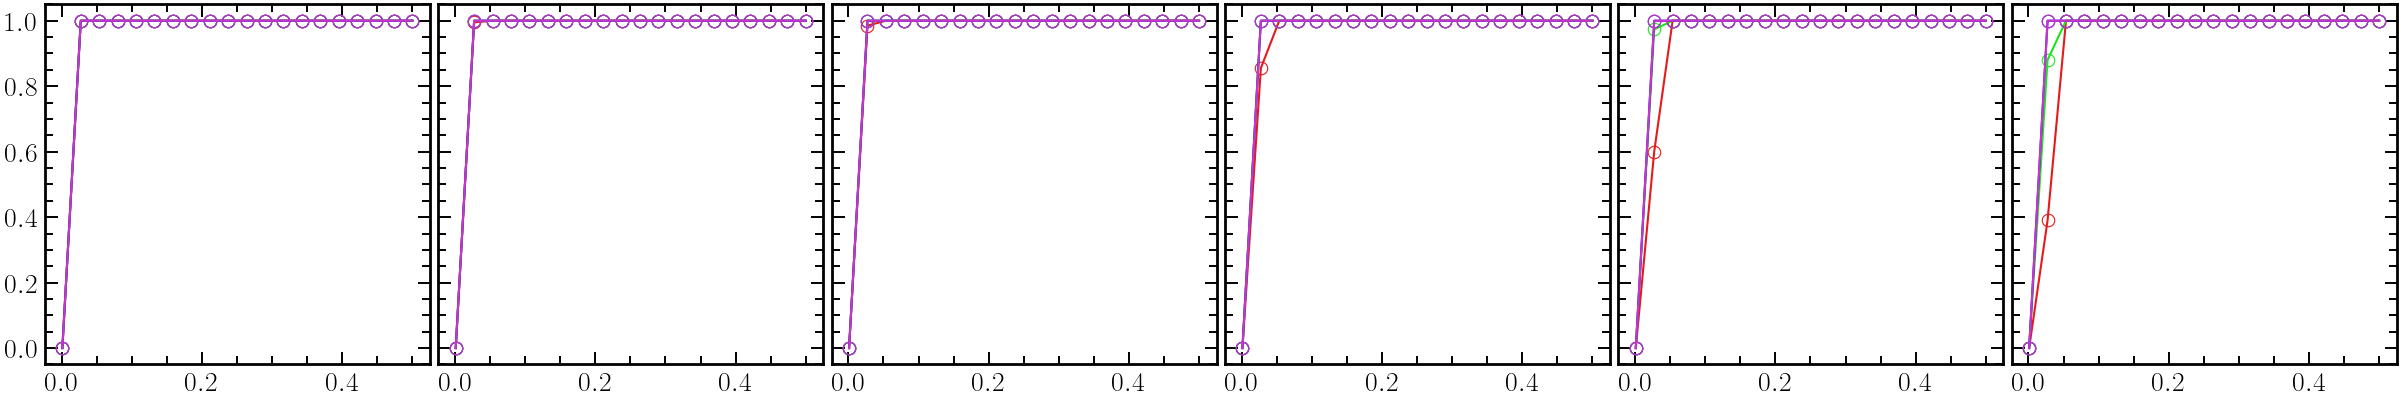

In [54]:
L_lst = [128, 256, 512, 1024]
ns = 1
#c_lst = [0.1, 0.01, 0.15, 0.2, 0.03, 0.05]
c_lst = [0.01, 0.03, 0.05, 0.1, 0.15, 0.2]
print(c_lst)
#c = 0.15
window = 300
base = 4
fig, axes = plt.subplots(1, len(c_lst), figsize=(len(c_lst)*base, base), constrained_layout=True, sharey='row', sharex='row')
markers = ['o', 's', 'D']
x_min = 0
f_lst = []

for idx, ax in enumerate(axes.flatten()):
    c = c_lst[idx]

    for L in L_lst:
        df_d = df_dynamic[(df_dynamic['c']==c) & (df_dynamic['num_colors']==ns) & (df_dynamic['p0']==0.6) & (df_dynamic['dim']==3) & (df_dynamic['L']==L) & (df_dynamic['stat_window']==window)]
        ft = df_d['f_T']
        nc = df_d['nc']
        ax.plot(ft, nc,'o-',label=f'$L= {L}$')
        fmin = min([f for f,nc in zip(ft,nc) if nc==ns])
        print(fmin)
        #f_lst.append(min(ft))
        

plt.show()



In [ ]:
L_lst = [128, 256, 512, 1024]
ns = 3
c_lst = [0.01, 0.03, 0.05, 0.1, 0.15, 0.2]

window = 300
base = 5
dim = 3

tick_fs = 16
label_fs = 18
tick_len = 8
tick_width = 1.4

fs_legend = 15
markers = ['o', 's', 'D', '^']
x_min = 0
ms = 7
mew = 1.4
pc = 0.5
order = 0
rho = round(1/ns, 5)
P0 = 1.0
p0 = 0.6
# ============================================================
# 1) Primeiro calcula ft_min e ft_max comuns para cada c
# ============================================================

ft_bounds = {}

for c in c_lst:
    ft_min_per_L = []
    ft_max_per_L = []

    # ----------------------------
    # ft_min vem da linha 1
    # ----------------------------
    for L in L_lst:
        df_d = df_dynamic[
            (np.isclose(df_dynamic['c'], c)) &
            (df_dynamic['num_colors'] == ns) &
            (df_dynamic['p0'] == p0) &
            (df_dynamic['P0'] == P0) &
            (df_dynamic['dim'] == dim) &
            (df_dynamic['L'] == L) &
            (df_dynamic['stat_window'] == window)
        ]

        ft_valid = df_d.loc[df_d['nc'] == ns, 'f_T'].dropna()

        if ft_valid.empty:
            raise ValueError(
                f"Nenhum ponto encontrado para calcular ft_min: "
                f"c={c}, L={L}, ns={ns}"
            )

        ft_min_per_L.append(ft_valid.min())

    # menor valor comum a todos os L
    ft_min = max(ft_min_per_L)

    # ----------------------------
    # ft_max vem da linha 2
    # depois do truncamento
    # ----------------------------
    for L in L_lst:
        df_s = df_series[
            (np.isclose(df_series['c'], c)) &
            (df_series['nc'] == ns) &
            (df_dynamic['p0'] == p0) &
            (df_dynamic['P0'] == P0) &
            (df_series['dim'] == dim) &
            (df_series['L'] == L) &
            (df_series['stat_window'] == window) &
            (df_series['order'] == order) &
            (np.isclose(df_series['rho'], rho))
        ]

        df_filter = df_s[
            (df_s['f_T'] >= ft_min)
        ]

        df_trunced = df_filter[
            df_filter['p_mean'] <= 0.95
        ].dropna(subset=['f_T', 'p_mean'])

        if df_trunced.empty:
            raise ValueError(
                f"Nenhum ponto encontrado para calcular ft_max: "
                f"c={c}, L={L}, ft_min={ft_min}"
            )

        ft_max_per_L.append(df_trunced['f_T'].max())

    # maior limite superior comum a todos os L
    ft_max = min(ft_max_per_L)

    ft_bounds[c] = {
        'ft_min': ft_min,
        'ft_max': ft_max
    }

    print(f"c={c:.2f} | ft_min={ft_min:.6g} | ft_max={ft_max:.6g}")


# ============================================================
# 2) Agora faz o plot usando os limites calculados
# ============================================================

fig, axes = plt.subplots(
    2, len(c_lst),
    figsize=(14, 6),
    sharey='row'
)

for ax in axes.flat:
    ax.set_box_aspect(1)

    ax.tick_params(
        axis='both',
        which='major',
        labelsize=tick_fs,
        length=tick_len,
        width=tick_width,
        direction='in',
        top=True,
        right=True
    )

    ax.tick_params(
        axis='both',
        which='minor',
        length=5,
        width=1.4,
        direction='in',
        top=True,
        right=True
    )

    ax.minorticks_on()

fig.subplots_adjust(
    left=0.06,
    right=0.98,
    bottom=0.12,
    top=0.92,
    wspace=0.005,
    hspace=0.12
)

# ============================================================
# Linha 1: <nc> versus f_T
# truncada pelo ft_max
# ============================================================

for idx, ax in enumerate(axes[0]):
    c = c_lst[idx]
    ft_min = ft_bounds[c]['ft_min']
    ft_max = ft_bounds[c]['ft_max']

    for idx_L, L in enumerate(L_lst):
        df_d = df_dynamic[
            (np.isclose(df_dynamic['c'], c)) &
            (df_dynamic['num_colors'] == ns) &
            (df_dynamic['p0'] == p0) &
            (df_dynamic['P0'] == P0) &
            (df_dynamic['dim'] == dim) &
            (df_dynamic['L'] == L) &
            (df_dynamic['stat_window'] == window)
        ]

        df_d = df_d[
            df_d['f_T'] <= ft_max
        ]

        ft = df_d['f_T']
        nc_plot = df_d['nc']

        ax.plot(
            ft, nc_plot,
            mew=mew,
            marker=markers[idx_L],
            ms=ms,
            ls='None',
            label=f'$L= {L}$',
            clip_on=False
        )

    ax.set_title(f'$c = {c}$')

    # Linha 1 truncada superiormente por ft_max
    ax.set_xlim(x_min, ft_max)

    if idx == 0:
        ax.set_ylabel(r'$\langle n_c \rangle$', fontsize=label_fs)
        ax.legend(fontsize=fs_legend)


# ============================================================
# Linha 2: p* versus f_T
# truncada por ft_min e ft_max
# ============================================================

for idx, ax in enumerate(axes[1]):
    c = c_lst[idx]
    ft_min = ft_bounds[c]['ft_min']
    ft_max = ft_bounds[c]['ft_max']

    for idx_L, L in enumerate(L_lst):
        df_s = df_series[
            (np.isclose(df_series['c'], c)) &
            (df_series['nc'] == ns) &
            (df_dynamic['p0'] == p0) &
            (df_dynamic['P0'] == P0) &
            (df_series['dim'] == dim) &
            (df_series['L'] == L) &
            (df_series['stat_window'] == window) &
            (df_series['order'] == order) &
            (np.isclose(df_series['rho'], rho))
        ]

        df_filter = df_s[
            (df_s['f_T'] >= ft_min) &
            (df_s['f_T'] <= ft_max)
        ]

        df_trunced = df_filter[
            df_filter['p_mean'] <= 0.95
        ]

        ft = df_trunced['f_T']
        pmean = df_trunced['p_mean']

        ax.plot(
            ft, pmean,
            marker=markers[idx_L],
            mew=mew,
            ms=ms,
            ls='None',
            label=f'$L= {L}$',
            clip_on=False
        )

    ax.axhline(y=pc, color='k', lw=2.0)

    ax.set_xlabel(r'$f_T$', fontsize=label_fs)
    ax.set_xlim(ft_min, ft_max)

    if idx == 0:
        ax.set_ylabel(r'$p^*$', fontsize=label_fs)
        ax.legend(fontsize=fs_legend, loc='upper left')

# plt.savefig(results_folder + "/nc_pmean.pdf", bbox_inches='tight')
plt.show()

ValueError: Nenhum ponto encontrado para calcular ft_max: c=0.01, L=128, ft_min=0.02726316

In [15]:
print(2**(9.25))

608.8740428813932


In [3]:
L_alvo = [128, 256, 512]
dim_alvo = 3

df_f = df[(df["dim"] == dim_alvo) & (df["L"].isin(L_alvo)) & (df["num_colors"]==4)].copy()

rhos_comuns = (
    df_f.groupby("rho")["L"]
        .nunique()
        .loc[lambda s: s == len(L_alvo)]
        .index
        .to_list()
)

print(rhos_comuns)

[0.001, 0.0022513, 0.0035025, 0.0047538, 0.006005, 0.0072563, 0.0085075, 0.0097588, 0.01101, 0.012261, 0.013513, 0.014764, 0.016015, 0.017266, 0.018518, 0.019769, 0.02102, 0.022271, 0.023523, 0.024774, 0.026025, 0.027276, 0.028528, 0.029779, 0.03103, 0.032281, 0.033533, 0.034784, 0.036035, 0.037286, 0.038538, 0.039789, 0.04104, 0.042291, 0.043543, 0.044794, 0.046045, 0.047296, 0.048548, 0.049799, 0.05105, 0.052302, 0.053553, 0.054804, 0.056055, 0.057307, 0.058558, 0.059809, 0.06106, 0.062312, 0.063563, 0.064814, 0.066065, 0.067317, 0.068568, 0.069819, 0.07107, 0.072322, 0.073573, 0.074824, 0.076075, 0.077327, 0.078578, 0.079829, 0.08108, 0.082332, 0.083583, 0.084834, 0.086085, 0.087337, 0.088588, 0.089839, 0.09109, 0.092342, 0.093593, 0.094844, 0.096095, 0.097347, 0.098598, 0.099849, 0.1011, 0.10235, 0.1036, 0.10485, 0.10611, 0.10736, 0.10861, 0.10986, 0.11111, 0.11236, 0.11361, 0.11486, 0.11612, 0.11737, 0.11862, 0.11987, 0.12112, 0.12237, 0.12362, 0.12487, 0.125, 0.12613, 0.12738, 0.

In [11]:
df = df[(df['dim']==3)]

## 2 COLORS

## 4 COLORS

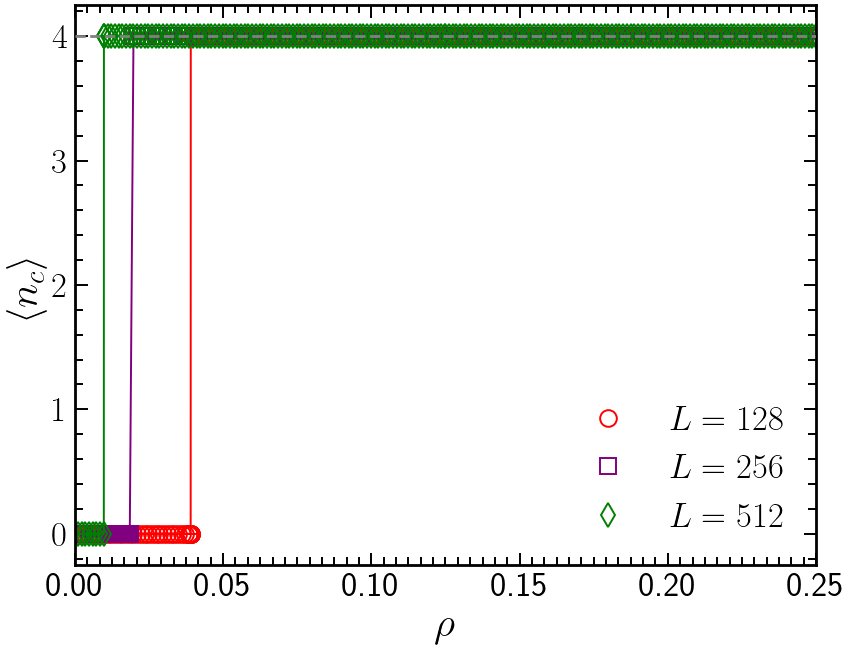

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from matplotlib.lines import Line2D

# -------- parâmetros do plot --------
num_colors_fix = 4
L_lst  = [128, 256, 512]

Nt_fix = 3000
k_fix  = 1.0e-06
dim = 3 
ms = 12
font_tick_size = 25
font_label_size = 30
font_legend_size = 25
colors  = ["red", "purple", "green", "blue"]
markers = ["o-", "s-", "d-", "^-"]
mew = 1.4
p0=0.1
thickness = 1.4

# se quiser fixar dim explicitamente (2 ou 3), defina aqui:
# dim_fix = 2
# dim_fix = 3
# ou deixe como None para não filtrar
dim_fix = None

# se quiser fixar p0 (recomendado se existir mais de um no df), defina aqui:
# p0_fix = 1.0
p0_fix = None


# ===== Figura e eixo principais =====
fig, ax = plt.subplots(figsize=(9, 7))
ax.xaxis.set_major_locator(MultipleLocator(0.05))
ax.xaxis.set_minor_locator(MultipleLocator(0.005))

legend_handles = []

for idx, L in enumerate(L_lst):
    res = df[(df['dim']==dim) & 
           (df['L']==L) & 
           (df['k']==k) & 
           (df['num_colors']==num_colors_fix) &
           (df['Nt']==Nt)]
    
    if res.empty:
        continue

    fmt   = markers[idx % len(markers)]
    color = colors [idx % len(colors)]
    
    # usa erro do próprio dataframe
    ax.errorbar(
        res['rho'], res["nc"], yerr=res["nc_err"],
        fmt=fmt, color=color, linewidth=thickness,
        ms=ms, markeredgewidth=mew, zorder=2,
        capsize=4, elinewidth=thickness
    )

    # Nsamples pode variar com rho; escolha um resumo (min) para o label
    ns_label = int(np.nanmin(res["Nsamples"].to_numpy())) if len(res) else 0

    label = fr"$L={L}$"
    legend_handles.append(Line2D(
        [], [], linestyle='None',
        marker=fmt[0], markersize=ms,
        markeredgewidth=mew, markerfacecolor='none',
        markeredgecolor=color, color=color, label=label
    ))

# ----- eixo principal -----
ax.axhline(y=num_colors_fix, color='gray', linestyle='--', lw=2.0, zorder=100)
ax.set_xlabel(r"$\rho$", fontsize=font_label_size)
ax.set_ylabel(r"$\langle n_c \rangle$", fontsize=font_label_size)
ax.set_ylim([-0.25, num_colors_fix + 0.25])

ax.set_xlim(0.0, 1.0/num_colors_fix)
major_locator = np.linspace(0.0, 1.0/num_colors_fix, 6)
minor_locator = np.linspace(0.0, 1.0/num_colors_fix, 61)
ax.set_xticks(major_locator)
ax.set_xticks(minor_locator, minor=True)
ax.set_xticklabels([f"{tick:.2f}" for tick in major_locator])

ax.tick_params(axis='both', which='major', labelsize=font_tick_size, length=9, width=thickness)
ax.tick_params(axis='x',   which='minor', length=6, width=thickness)

ax.legend(handles=legend_handles, fontsize=font_legend_size, loc="lower right", frameon=False)

plt.tight_layout()

# título
# if dim_fix is not None:
#     ax.set_title(f"dim = {dim_fix}")
# else:
#     ax.set_title(rf"dim $= {dim}$, $n_c = {num_colors_fix}$, $N_t$ $= {Nt_fix}$, $k = ${k_fix:.1e}, $p0 = {p0}$")

# fig.savefig(
#     savepath + f"/nc_{num_colors_fix}_dim_{dim}.png",
#     dpi=300,
#     bbox_inches="tight",
#     pad_inches=0.05
# )
plt.show()

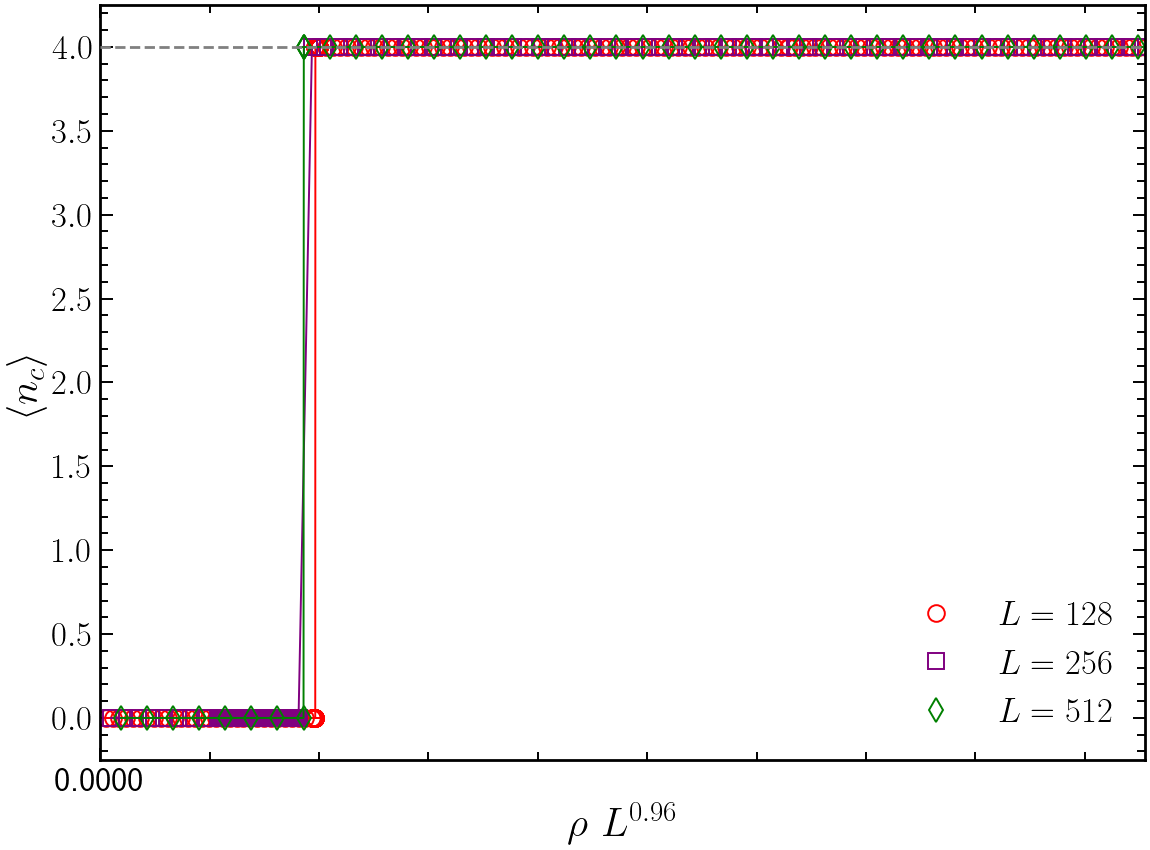

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from matplotlib.lines import Line2D

# -------- parâmetros do plot --------
num_colors_fix = 4
L_lst  = [128, 256, 512]

Nt_fix = 3000
k_fix  = 1.0e-06
dim = 3 
ms = 12
font_tick_size = 25
font_label_size = 30
font_legend_size = 25
colors  = ["red", "purple", "green", "blue"]
markers = ["o-", "s-", "d-", "^-"]
mew = 1.4
p0 = 0.1
thickness = 1.4

# mantém exatamente como no original
dim_fix = None
p0_fix = None


# ===== Figura e eixo principais =====
fig, ax = plt.subplots(figsize=(12, 9))
ax.xaxis.set_major_locator(MultipleLocator(0.0005))
ax.xaxis.set_minor_locator(MultipleLocator(0.00005))

legend_handles = []

x_all = []
exp = 0.96

for idx, L in enumerate(L_lst):
    res = df[(df['dim']==dim) & 
           (df['L']==L) & 
           (df['k']==k) & 
           (df['num_colors']==num_colors_fix) &
           (df['Nt']==Nt)]

    if res.empty:
        print(f"[WARN] Nenhum dado encontrado para L={L}")
        continue

    fmt   = markers[idx % len(markers)]
    color = colors[idx % len(colors)]

    # como você pediu: rho/L
    x_res = L**(exp) * res["rho"].to_numpy(dtype=float)
    y_res = res["nc"].to_numpy(dtype=float)
    yerr_res = res["nc_err"].to_numpy(dtype=float)

    x_all.extend(x_res.tolist())

    ax.errorbar(
        x_res, y_res, yerr=yerr_res,
        fmt=fmt, color=color, linewidth=thickness,
        ms=ms, markeredgewidth=mew, zorder=2,
        capsize=4, elinewidth=thickness,
        markerfacecolor='none'
    )

    label = fr"$L={L}$"
    legend_handles.append(
        Line2D(
            [], [], linestyle='None',
            marker=fmt[0], markersize=ms,
            markeredgewidth=mew, markerfacecolor='none',
            markeredgecolor=color, color=color, label=label
        )
    )

# ----- eixo principal -----
ax.axhline(y=num_colors_fix, color='gray', linestyle='--', lw=2.0, zorder=100)
ax.set_xlabel(fr"$\rho$ $L^{{{exp}}}$", fontsize=font_label_size)
ax.set_ylabel(r"$\langle n_c \rangle$", fontsize=font_label_size)
ax.set_ylim([-0.25, num_colors_fix + 0.25])

# ajusta xlim ao novo eixo rho/L
if len(x_all) > 0:
    xmax = max(x_all)
    ax.set_xlim(0.0, 1.05 * xmax)

    major_xticks = np.linspace(0.0, 1.05 * xmax, 6)
    minor_xticks = np.linspace(0.0, 1.05 * xmax, 51)
    ax.set_xticks(major_xticks)
    ax.set_xticks(minor_xticks, minor=True)
    ax.set_xticklabels([f"{tick:.4f}" for tick in major_xticks])
ax.set_xlim([0, 20])
ax.tick_params(axis='both', which='major', labelsize=font_tick_size, length=9, width=thickness)
ax.tick_params(axis='both', which='minor', length=6, width=thickness)

ax.legend(handles=legend_handles, fontsize=font_legend_size, loc="lower right", frameon=False)

plt.tight_layout()

# fig.savefig(
#     savepath + f"/nc_{num_colors_fix}_dim_{dim}_rho_over_L.png",
#     dpi=300,
#     bbox_inches="tight",
#     pad_inches=0.05
# )

plt.show()

In [3]:
df_sub = df[(df['dim']==3) & (df["L"]==512) & (df["num_colors"]==4)]
df_nc0 = df_sub[np.isclose(df_sub["nc"], 0.0)]
df_nc0['rho'].unique()

df_sub_sorted = df_sub.sort_values("rho")

mask = ~np.isclose(df_sub_sorted["nc"], 0.0)  # tolerância p/ float
df_first = df_sub_sorted.loc[mask].iloc[0] if mask.any() else None
df_first

L              512.000000
dim              3.000000
Nt            3000.000000
k                0.000001
num_colors       4.000000
p0               1.000000
Nsamples        50.000000
rho              0.009771
nc               4.000000
nc_err           0.000000
Name: 1624, dtype: float64

## 8 COLORS

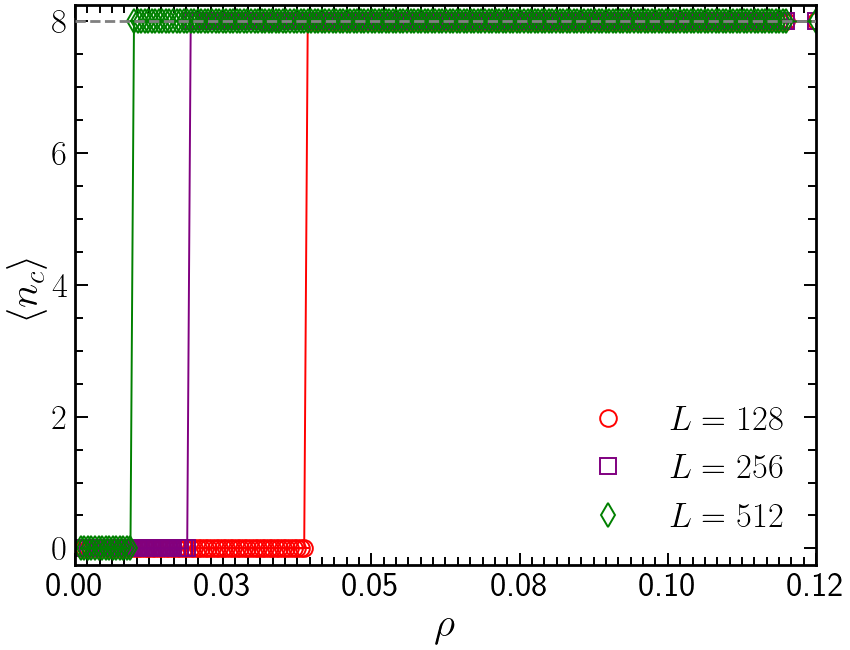

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from matplotlib.lines import Line2D

# -------- parâmetros do plot --------
num_colors_fix = 8
L_lst  = [128, 256, 512]

Nt_fix = 3000
k_fix  = 1.0e-06

ms = 12
font_tick_size = 25
font_label_size = 30
font_legend_size = 25
colors  = ["red", "purple", "green", "blue"]
markers = ["o-", "s-", "d-", "^-"]
mew = 1.4
thickness = 1.4

# se quiser fixar dim explicitamente (2 ou 3), defina aqui:
# dim_fix = 2
# dim_fix = 3
# ou deixe como None para não filtrar
dim_fix = None

# se quiser fixar p0 (recomendado se existir mais de um no df), defina aqui:
# p0_fix = 1.0
p0_fix = None


def nc_by_rho_from_df(df, n_colors, L, k, Nt, dim=None, p0=None):
    sel = df.copy()

    sel = sel[sel["num_colors"] == n_colors]
    sel = sel[sel["L"] == L]

    if dim is not None:
        sel = sel[sel["dim"] == dim]

    if k is not None:
        sel = sel[np.isclose(sel["k"].astype(float), float(k), rtol=1e-12, atol=0.0)]

    if Nt is not None:
        sel = sel[sel["Nt"] == Nt]

    if p0 is not None:
        sel = sel[np.isclose(sel["p0"].astype(float), float(p0), rtol=1e-12, atol=0.0)]

    if sel.empty:
        return pd.DataFrame(columns=["rho", "nc", "nc_err", "Nsamples"])

    # (rho é float, garanta ordenação)
    sel["rho"] = sel["rho"].astype(float)
    sel = sel.sort_values("rho").reset_index(drop=True)

    # Se ainda existir mais de um p0 por rho (p0_fix=None e dataset tem múltiplos p0),
    # agregue por rho usando média ponderada por Nsamples.
    if p0 is None and sel.groupby("rho")["p0"].nunique().max() > 1:
        def _wmean(g):
            w = g["Nsamples"].to_numpy(dtype=float)
            y = g["nc"].to_numpy(dtype=float)
            e = g["nc_err"].to_numpy(dtype=float)

            wsum = w.sum()
            if wsum <= 0:
                return pd.Series({"nc": np.nan, "nc_err": np.nan, "Nsamples": 0})

            nc_w = np.sum(w * y) / wsum
            # propagação simples de erro (assumindo independência)
            nc_err_w = np.sqrt(np.sum((w * e) ** 2)) / wsum

            return pd.Series({"nc": nc_w, "nc_err": nc_err_w, "Nsamples": int(wsum)})

        sel = sel.groupby("rho", as_index=False).apply(_wmean)

    return sel[["rho", "nc", "nc_err", "Nsamples"]]


# ===== Figura e eixo principais =====
fig, ax = plt.subplots(figsize=(9, 7))
ax.xaxis.set_major_locator(MultipleLocator(0.05))
ax.xaxis.set_minor_locator(MultipleLocator(0.005))

legend_handles = []

for idx, L in enumerate(L_lst):
    res = nc_by_rho_from_df(df, n_colors=num_colors_fix, L=L, k=k_fix, Nt=Nt_fix,
                           dim=dim_fix, p0=p0_fix)
    if res.empty:
        continue

    fmt   = markers[idx % len(markers)]
    color = colors [idx % len(colors)]

    # usa erro do próprio dataframe
    ax.errorbar(
        res["rho"], res["nc"], yerr=res["nc_err"],
        fmt=fmt, color=color, linewidth=thickness,
        ms=ms, markeredgewidth=mew, zorder=2,
        capsize=4, elinewidth=thickness
    )

    # Nsamples pode variar com rho; escolha um resumo (min) para o label
    ns_label = int(np.nanmin(res["Nsamples"].to_numpy())) if len(res) else 0

    label = fr"$L={L}$"
    legend_handles.append(Line2D(
        [], [], linestyle='None',
        marker=fmt[0], markersize=ms,
        markeredgewidth=mew, markerfacecolor='none',
        markeredgecolor=color, color=color, label=label
    ))

# ----- eixo principal -----
ax.axhline(y=num_colors_fix, color='gray', linestyle='--', lw=2.0, zorder=100)
ax.set_xlabel(r"$\rho$", fontsize=font_label_size)
ax.set_ylabel(r"$\langle n_c \rangle$", fontsize=font_label_size)
ax.set_ylim([-0.25, num_colors_fix + 0.25])

ax.set_xlim(0.0, 1.0/num_colors_fix)
major_locator = np.linspace(0.0, 1.0/num_colors_fix, 6)
minor_locator = np.linspace(0.0, 1.0/num_colors_fix, 61)
ax.set_xticks(major_locator)
ax.set_xticks(minor_locator, minor=True)
ax.set_xticklabels([f"{tick:.2f}" for tick in major_locator])

ax.tick_params(axis='both', which='major', labelsize=font_tick_size, length=9, width=thickness)
ax.tick_params(axis='x',   which='minor', length=6, width=thickness)

ax.legend(handles=legend_handles, fontsize=font_legend_size, loc="lower right", frameon=False)

plt.tight_layout()

# título
# if dim_fix is not None:
#     ax.set_title(f"dim = {dim_fix}")
# else:
#     ax.set_title(rf"dim $= {dim}$, $n_c = {num_colors_fix}$, $N_t$ $= {Nt_fix}$, $k = ${k_fix:.1e}, $p0 = {p0}$")

fig.savefig(
    savepath + f"/nc_{num_colors_fix}_dim_{dim}.png",
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.05
)
plt.show()


In [11]:
df_sub = df[(df['dim']==3) & (df["L"]==128) & (df["num_colors"]==8)]
df_nc0 = df_sub[np.isclose(df_sub["nc"], 0.0)]
df_nc0['rho'].unique()

df_sub_sorted = df_sub.sort_values("rho")

mask = ~np.isclose(df_sub_sorted["nc"], 0.0)  # tolerância p/ float
df_first = df_sub_sorted.loc[mask].iloc[0] if mask.any() else None
df_first

L              128.000000
dim              3.000000
Nt            3000.000000
k                0.000001
num_colors       8.000000
p0               1.000000
Nsamples       500.000000
rho              0.039271
nc               8.000000
nc_err           0.000000
Name: 565, dtype: float64

In [16]:
df.head()

,L,n_colors,NT,n_c,n_c_err,rho,k,Nsamples
0,128,2,1600,2.0,0.0,0.000100,0.00001,1000
1,128,2,1600,2.0,0.0,0.006428,0.00001,1000
2,128,2,1600,2.0,0.0,0.012756,0.00001,1000
3,128,2,1600,2.0,0.0,0.019084,0.00001,1000
4,128,2,1600,2.0,0.0,0.025411,0.00001,1000


In [10]:
df["L"].unique()

array([ 128,  192,  256,  384,  512,  768, 1024, 2000, 2048, 4096, 8192])

In [57]:
def linear_regression(L_lst, rho_min):
    xL = np.asarray(L_lst, dtype=float)
    yR = np.asarray(rho_min, dtype=float)

    # segurança (log exige >0)
    mask = (xL > 0) & (yR > 0)
    xL = xL[mask]
    yR = yR[mask]

    # --- regressão em log2-log2: y = B x + c, onde c = log2(A) ---
    x = np.log2(xL)
    y = np.log2(yR)

    n = x.size
    xbar = x.mean()
    ybar = y.mean()

    Sxx = np.sum((x - xbar)**2)
    Sxy = np.sum((x - xbar)*(y - ybar))

    B = Sxy / Sxx
    c = ybar - B * xbar  # c = log2(A)

    # resíduos e variância estimada
    yhat = B * x + c
    res = y - yhat
    SSE = np.sum(res**2)
    s2 = SSE / (n - 2)              # variância residual (OLS)
    s = np.sqrt(s2)

    # erros padrão dos parâmetros em (B, c)
    sigma_B = np.sqrt(s2 / Sxx)
    sigma_c = np.sqrt(s2 * (1.0/n + xbar**2 / Sxx))

    # --- converte para A e incerteza de A ---
    A = 2**c
    # A = 2^c  =>  ln A = c ln 2  =>  sigma_A = A * ln(2) * sigma_c
    sigma_A = A * np.log(2.0) * sigma_c

    print(f"A = {A:.6g} ± {sigma_A:.2g}")
    print(f"B = {B:.6g} ± {sigma_B:.2g}")

    L_fit = np.linspace(xL.min(), xL.max(), 400)
    rho_fit = A * L_fit**B
    return L_fit, rho_fit, A, sigma_A, B, sigma_B

In [64]:
L_lst = [128, 192, 256, 384, 512]
rho_min = []
n_colors = 8
nc = n_colors
for L in L_lst:
    rho = df[(df["L"]==L) & (df['dim']==3) & (df["num_colors"]==n_colors) & (df["nc"]==nc)]['rho'].min()
    rho_min.append(rho)
print(rho_min)

[0.039271, 0.026116, 0.019538, 0.013558, 0.0099699]


A = 3.3599 ± 0.72
B = -0.922695 ± 0.037


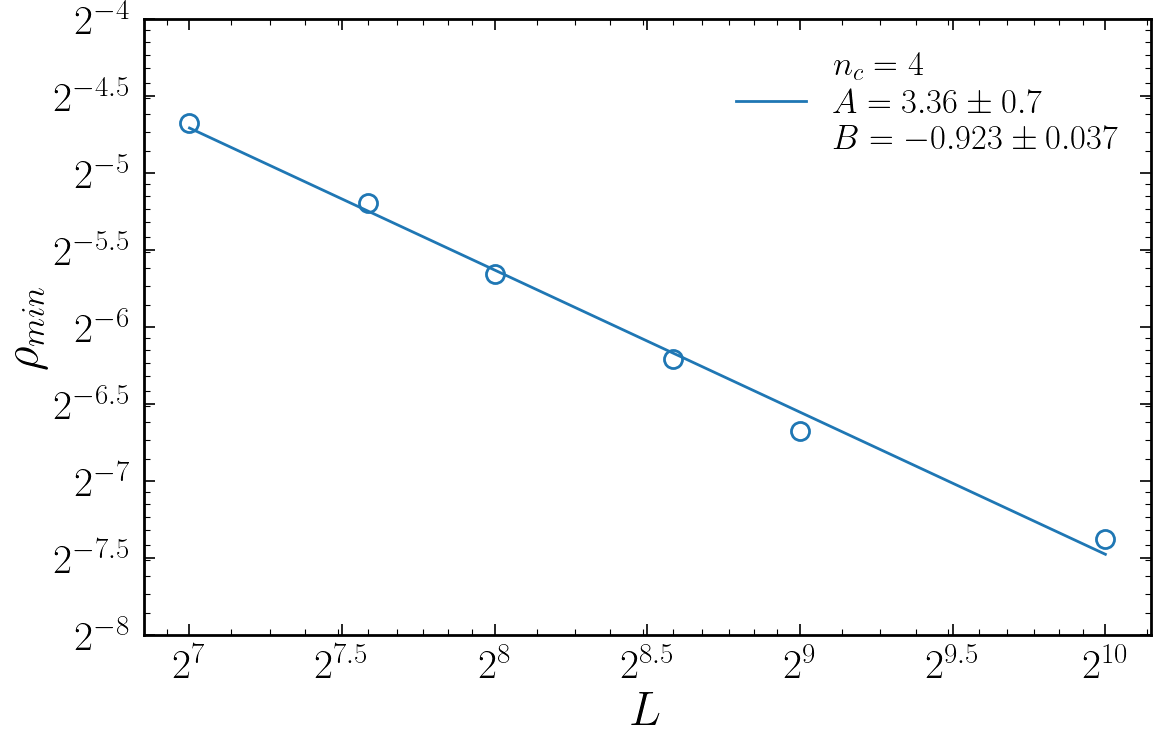

In [79]:
from matplotlib.ticker import FuncFormatter
from matplotlib.ticker import LogLocator, NullFormatter
L_lst = [128, 192, 256, 384, 512, 1024]
rho_min = []
n_colors = 4
nc = n_colors
for L in L_lst:
    rho = df[(df["L"]==L) & (df['dim']==3) & (df["num_colors"]==n_colors) & (df["nc"]==nc)]['rho'].min()
    rho_min.append(rho)

fig, ax = plt.subplots(figsize=(13,8))
mew=2.0
ms = 13
fs_label = 35
fs_ticks = 30
fs_legend = 25


colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
markers = ["o", "^", "s"]

x = np.log2(np.array(L_lst))
y = np.log2(np.array(rho_min))
a, b = np.polyfit(x, y, 1)

#=======================
# --- dados ---
L_fit, rho_fit, A, sigma_A, B, sigma_B = linear_regression(L_lst, rho_min)

ax.plot(
    L_fit,
    rho_fit,
    '-',
    lw=2.0,
    color=colors[0],
    label=(
        fr"$n_c = {n_colors}$" "\n"
        r"$A = {:.3g} \pm {:.1g}$" "\n"
        r"$B = {:.3f} \pm {:.3f}$"
    ).format(A, sigma_A, B, sigma_B)
)

ax.plot(L_lst, rho_min, 'o', color=colors[0], mew=mew, ms=ms)
ax.set_xscale("log", base=2)
ax.set_yscale("log", base=2)

# -------------------------
# Função formatadora
# -------------------------
def log2_formatter(val, pos):
    exponent = np.log2(val)
    if abs(exponent - round(exponent)) < 1e-8:
        return rf"$2^{{{int(round(exponent))}}}$"
    else:
        return rf"$2^{{{exponent:.1f}}}$"

# -------------------------
# X ticks
# -------------------------
exp_min_x = int(np.floor(np.log2(min(L_lst))))
exp_max_x = int(np.ceil(np.log2(max(L_lst))))
exponents_x = np.arange(exp_min_x, exp_max_x + 0.5, 0.5)

ax.set_xticks(2**exponents_x)
ax.xaxis.set_major_formatter(FuncFormatter(log2_formatter))

# -------------------------
# Y ticks
# -------------------------
ymin, ymax = ax.get_ylim()

exp_min_y = np.floor(np.log2(ymin))
exp_max_y = np.ceil(np.log2(ymax))

exponents_y = np.arange(exp_min_y, exp_max_y + 0.5, 0.5)

ax.set_yticks(2**exponents_y)
ax.yaxis.set_major_formatter(FuncFormatter(log2_formatter))

n_sub = 10  # número de divisões no intervalo log

# cria subdivisões uniformes no expoente
subs = 1 + np.arange(1, n_sub) / n_sub

# eixo X
ax.xaxis.set_minor_locator(LogLocator(base=2, subs=subs))
ax.xaxis.set_minor_formatter(NullFormatter())

# eixo Y
ax.yaxis.set_minor_locator(LogLocator(base=2, subs=subs))
ax.yaxis.set_minor_formatter(NullFormatter())

# ajuste visual opcional
# major ticks
ax.tick_params(axis='both', which='major',
               pad=10,      # distância do número
               length=8,
               width=1.2,
               labelsize=fs_ticks)

# minor ticks (normalmente sem label)
ax.tick_params(axis='both', which='minor',
               length=4,
               width=0.8)

ax.set_ylabel(r'$\rho_{min}$',fontsize=fs_label)
ax.set_xlabel(r'$L$',fontsize=fs_label)
ax.legend(fontsize=fs_legend)
plt.savefig(savepath + "/rho_min.pdf")
plt.show()